# Show online map

In [1]:
import osmnx as ox
import pandas as pd
from fit import fit_to_route
from matplotlib import pyplot as plt
from route import Coord

In [ ]:
# offline
ox.settings.use_cache = True
ox.settings.log_console = True

# settings
me = Coord(51.75866, -1.261, units='°')
dist = 500 # m

# extract a small subgraph around your point
G = ox.graph_from_point(
    me.lat_long('°'),
    dist=dist,
    dist_type="bbox",
    network_type="bike",
    simplify=True,
    retain_all=False,
    truncate_by_edge=True,
)

# plot
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="black",
    edge_linewidth=1.5,
    bgcolor="white",
    show=False,
    close=False
)
# plt.savefig("map.png", dpi=200, bbox_inches="tight")

# Overlay pre-determined route

`osmnx` also has its own [routing](https://osmnx.readthedocs.io/en/stable/getting-started.html#routing) if feeling brave

{'distance_until_instruction': np.float64(65.34322832493659),
 'text': "Continue onto St Giles'",
 'total_distance_covered_along_route': np.float64(1414.6567716750635)}

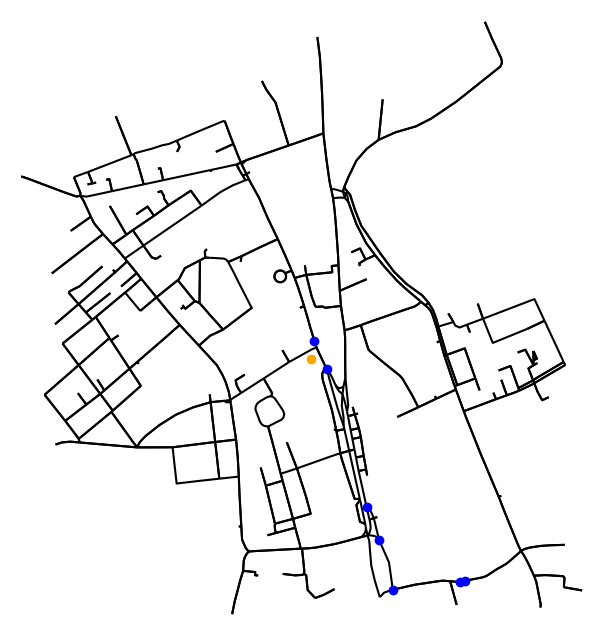

In [ ]:
route = fit_to_route('stav_to_trin.fit')
cues = pd.read_csv('stav_to_trin_cuesheet.csv')
route.set_instructions_text(cues['Notes'])
route.set_instructions_icons(cues['Type'])
route.set_elevations(cues['Elevation (m)'])


fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color="black",
    edge_linewidth=1.5,
    bgcolor="white",
    show=False,
    close=False
)
for inst in route.instructions:
    ax.plot(*inst.coord.long_lat('°'), 'o', c='b')
ax.plot(*me.long_lat('°'), 'o', c='orange')

route.instruct(me)